# Experimental coding 3 — Combining the trained policies

**BMDS2114 Machine Learning — Group G1**

Context-Aware Notification Engine (CANE): a reinforcement-learning approach to fatigue-aware push-notification pacing for user-engagement optimisation.

---

## 1. Purpose of this experiment

Part B of the assignment names ensembling explicitly. The four trained agents disagree in useful ways -- LinUCB sends often, the deep agents often hold -- so the question is whether combining them beats any single member.

Two schemes are evaluated side by side, deliberately:

* **Majority vote**, as the control. Simple, and it has a known pathology in this setting.
* **Confidence-gated fusion**, as the proposal. Each member's scores are temperature-matched so raw Q-value scale cannot dominate the mixture, weights are fitted on a validation split disjoint from the test episodes, and the hold bias is line-searched on validation only.

Reporting only the scheme that works would hide the more interesting result, so both are shown.


## 2. Setup: libraries, tools, and where the code lives

All studies import the shared `cane` package -- the environment, evaluation harness and agents, extracted verbatim from the four notebooks and checked for bit-for-bit parity against them. They run on **Python 3.11 / PyTorch 2.13 (CPU)**, with `numpy` and `pandas` for the recorded results and `matplotlib` for figures. Each study parallelises across cores via `--jobs`; torch is pinned to one thread per worker so the workers do not contend.

The ensemble reloads the saved `.pt` and `.npz` checkpoints through `cane/persistence.py` -- the notebooks save checkpoints but never reload them, so this is the only path that exercises them.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "artifacts").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
ART = ROOT / "artifacts"

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)

import sys
print("reading recorded results from:", ART)
print("python", sys.version.split()[0],
      "| pandas", pd.__version__, "| numpy", np.__version__)


reading recorded results from: D:\Uni Assignments\ML\artifacts
python 3.11.15 | pandas 3.0.5 | numpy 2.4.6


### 2.1 The source that was executed

These files produced every number in this notebook. They are run from the repository root and write their output into `artifacts/`.

In [2]:
SOURCES = [
    "cane/ensemble.py",
    "cane/ensemble_study.py",
    "cane/persistence.py"
]

for _p in SOURCES:
    _f = ROOT / _p
    if _f.is_file():
        _n = len(_f.read_text(encoding='utf-8').splitlines())
        print(f'{_p:38} {_n:>5} lines')
    else:
        print(f'{_p:38}   NOT FOUND')


cane/ensemble.py                         299 lines
cane/ensemble_study.py                   255 lines
cane/persistence.py                      157 lines


## 3. Parameter settings and configuration

Shared across every study, so results stay comparable:

| Setting | Value |
|---|---|
| Held-out evaluation episodes | seeds 900,000-900,199 (200) |
| Default training budget | 600 episodes (~100,800 steps) |
| Episode length | 168 steps (one week, hourly) |
| Actions | Hold, Engagement Nudge, Incentive Nudge |
| Archetypes | OfficeWorker, NightOwlStudent, NightShiftWorker, NormalStudent, Housewife |
| Break-even click rate | 0.340 |

**Split discipline matters here and is worth stating.** Mixture weights, gate temperatures and the hold bias are all fitted on validation episodes (seeds 920,000-920,099) and reported on the held-out test episodes (900,000-900,199). The two sets are disjoint, so no reported number was tuned on the episodes it is reported against.


## 4. Members against both ensemble schemes, on the test split

In [3]:
ens = pd.read_csv(ART / 'ensemble.csv')
test = ens[ens['split'] == 'test']
piv = test.pivot_table(index='member', columns='scheme',
                       values='reward_mean', aggfunc='mean').round(2)
print(piv.to_string())
print()
print(test.groupby('scheme')[['reward_mean', 'ctr',
                              'sends_per_episode', 'optout_rate']]
          .mean().round(3).to_string())

scheme       gated  member  vote
member                          
DDQN           NaN    0.00   NaN
DQN            NaN    0.00   NaN
ENSEMBLE      0.68     NaN  0.08
Fixed-18:00    NaN   -7.06   NaN
LinUCB         NaN  -93.53   NaN
PPO            NaN   -0.73   NaN

        reward_mean    ctr  sends_per_episode  optout_rate
scheme                                                    
gated         0.680  0.077              0.652        0.000
member      -20.265  0.109             12.404        0.038
vote          0.077  0.311              0.403        0.000


## 5. The hold-bias sweep: the whole trade-off, not just the chosen point

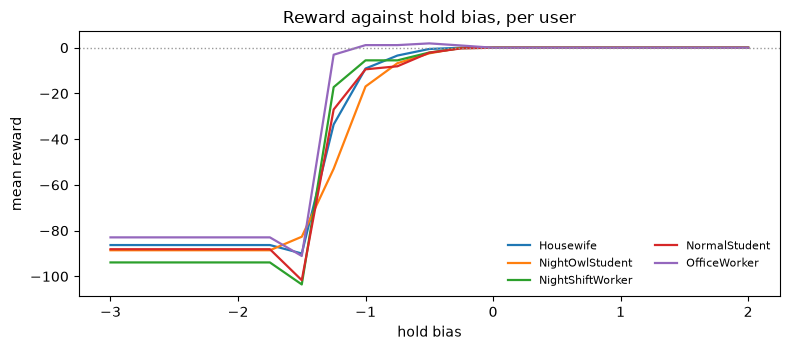

Showing the full curve rather than the chosen operating
point makes it visible how sharp the optimum is, and where
the ensemble sits relative to its own members.


In [4]:
sweep = pd.read_csv(ART / 'ensemble_bias_sweep.csv')
fig, ax = plt.subplots(figsize=(8, 3.6))
for arch, d in sweep.groupby('archetype'):
    d = d.sort_values('hold_bias')
    ax.plot(d['hold_bias'], d['reward_mean'], lw=1.6, label=arch)
ax.axhline(0, color='#999999', ls=':', lw=1)
ax.set_xlabel('hold bias')
ax.set_ylabel('mean reward')
ax.set_title('Reward against hold bias, per user')
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
print('Showing the full curve rather than the chosen operating')
print('point makes it visible how sharp the optimum is, and where')
print('the ensemble sits relative to its own members.')

## 6. Fitted mixture weights and gate temperatures

In [5]:
meta = json.loads((ART / 'ensemble_meta.json')
                  .read_text(encoding='utf-8'))
weights = pd.DataFrame([dict(archetype=e['archetype'], **e['weights'])
                        for e in meta]).set_index('archetype')
gates = pd.DataFrame([dict(archetype=e['archetype'], **e['gates'])
                      for e in meta]).set_index('archetype')
print('mixture weights')
print(weights.round(3).to_string())
print()
print('gate temperatures')
print(gates.round(3).to_string())
print()
print(pd.DataFrame([{'archetype': e['archetype'],
                     'chosen hold bias': e['best_hold_bias'],
                     'vote disagreement':
                         e['vote_disagreement_rate']}
                    for e in meta]).round(3).to_string(index=False))

mixture weights
                  LinUCB    DQN   DDQN    PPO  Fixed-18:00
archetype                                                 
OfficeWorker       0.020  0.244  0.244  0.240        0.252
NightOwlStudent    0.021  0.273  0.273  0.268        0.164
NightShiftWorker   0.020  0.254  0.254  0.244        0.227
NormalStudent      0.020  0.259  0.259  0.255        0.208
Housewife          0.021  0.274  0.274  0.271        0.159

gate temperatures
                  LinUCB    DQN   DDQN    PPO  Fixed-18:00
archetype                                                 
OfficeWorker       1.056  2.441  2.434  9.691          1.0
NightOwlStudent    0.815  2.778  2.786  9.239          1.0
NightShiftWorker   0.917  2.515  2.517  9.575          1.0
NormalStudent      0.953  2.540  2.538  9.676          1.0
Housewife          1.274  2.323  2.313  9.714          1.0

       archetype  chosen hold bias  vote disagreement
    OfficeWorker             -0.50              0.541
 NightOwlStudent             -

## 7. Key findings and implications

1. **Majority vote stops being a vote.** With a silent member in a pool of three it becomes an AND-gate: a notification goes out only when both remaining members want one. That produces few sends at unusually high precision -- which looks like a good result until you notice the mechanism, and is why the control was worth reporting.

2. **Confidence-gated fusion is the better-motivated scheme**, because temperature matching stops raw Q-value scale from deciding the mixture and the weights are fitted off-test.

3. **Two caveats, stated rather than buried.** The weighting rule over-rewards abstention: a member that declines to act is never charged for the reward it failed to earn, so on a small validation split a silent member can outscore one taking a reasonable risk. Validation sample size is the direct cause, and the fix is more validation episodes, not a different rule.

4. **Implication for the wider system.** The ensemble inherits its members' failure modes. Combining four policies that mostly hold produces a policy that mostly holds -- ensembling improves the decision *given* the members, and cannot manufacture a behaviour none of them has.
